In [85]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pprint import pprint
import os

In [86]:
load_dotenv()

True

In [87]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [88]:
subgraph_llm = ChatOpenAI(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY"),
    base_url=os.getenv("GROQ_BASE_URL"),
)

In [89]:
def translate_text(state: SubState):

    prompt = f"""
        Translate the following text into Hindi.

        Requirements:
        - Output ONLY the Hindi translation.
        - Use Devanagari script (हिन्दी).
        - Do not use English unless a technical term has no natural Hindi equivalent.
        - Do not explain the translation.
        - Do not add extra content.

        Text:
        {state["input_text"]}
        """.strip()
            
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

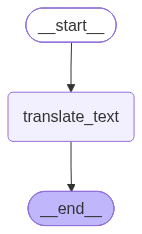

In [90]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

subgraph

In [91]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [92]:
parent_llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY"),
    base_url=os.getenv("GROQ_BASE_URL"),
    max_tokens=300,
    temperature=0.5,
)

In [93]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [94]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    print(result)

    return {'answer_hin': result}


In [95]:
response = subgraph_llm.invoke("""
Translate this sentence into Hindi.

Use Devanagari script:
Artificial intelligence is changing the way we work and learn.

Output only the Hindi translation.
""")

print(response.content)

कृत्रिम बुद्धिमत्ता हमारे काम और सीखने के तरीके को बदल रही है।


In [96]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

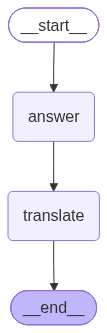

In [97]:
graph = parent_builder.compile()

graph

In [100]:
response = graph.invoke({'question': 'What is the actual power of AI in short without table'})

{'input_text': 'AI’s real power lies in its ability to **process massive amounts of data, recognize patterns, and make predictions or decisions far faster and often more accurately than humans**—all while continuously learning and adapting. This enables it to automate repetitive tasks, uncover insights hidden in complex datasets, personalize experiences, and augment human creativity and decision‑making across fields such as healthcare, finance, transportation, and entertainment. However, AI is limited to the quality of its training data, lacks true understanding or consciousness, and must be guided by ethical, transparent, and domain‑expert oversight to avoid bias, errors, or misuse.', 'translated_text': 'AI की वास्तविक शक्ति इसके विशाल मात्रा के डेटा को प्रोसेस करने, पैटर्न पहचानने और मानवों की तुलना में काफी तेज़ और अक्सर अधिक सटीक रूप से भविष्यवाणी या निर्णय लेने की क्षमता में निहित है—साथ ही यह लगातार सीखता और अनुकूलित होता रहता है। यह इसे दोहरावदार कार्यों को स्वचालित करने, जटिल ड

In [101]:
pprint(response)

{'answer_eng': 'AI’s real power lies in its ability to **process massive '
               'amounts of data, recognize patterns, and make predictions or '
               'decisions far faster and often more accurately than '
               'humans**—all while continuously learning and adapting. This '
               'enables it to automate repetitive tasks, uncover insights '
               'hidden in complex datasets, personalize experiences, and '
               'augment human creativity and decision‑making across fields '
               'such as healthcare, finance, transportation, and '
               'entertainment. However, AI is limited to the quality of its '
               'training data, lacks true understanding or consciousness, and '
               'must be guided by ethical, transparent, and domain‑expert '
               'oversight to avoid bias, errors, or misuse.',
 'answer_hin': {'input_text': 'AI’s real power lies in its ability to '
                              '**pr